# Lab 4: Validation Metrics Practice

You have been given a dataset that represents a series of credit card transactions. You would like to be able to predict which ones are fradulent. Dataset is taken from: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud/data and can also be found on D2L.

In [1]:
# Import libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

Import dataset and split into feature matrix and target vector. Are there any columns that should be removed?

In [2]:
data = pd.read_csv('creditcard.csv')
X = data.drop(columns=['Time','Class'])
y = data['Class']

X.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99


**Question**: Is this dataset unbalanced?

In [3]:
# Check the distribution of each class
y.value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

Repeat the same analysis as the breast cancer example:

In [4]:
# Split data and train logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split

# Split the dataset into training and validation sets (use 20% testing split and random_state=42)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y, random_state=42)

# Train a linear classifier - increase max_iter if needed
logreg = LogisticRegression(max_iter=1000)

logreg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

Accuracy: 1.00
Precision: 0.83
Recall: 0.65
F1-Score: 0.73
ROC-AUC: 0.83
Precision-Recall AUC: 0.54


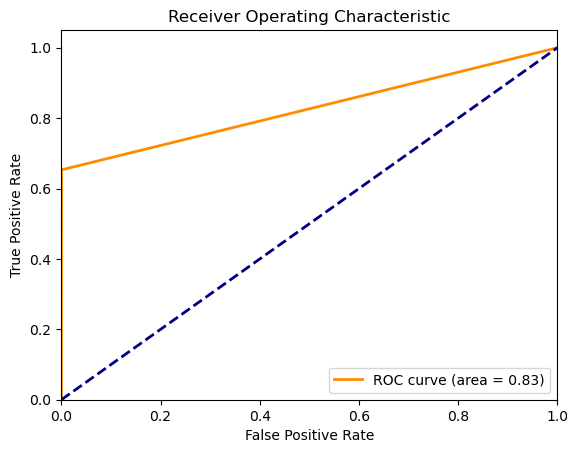

In [5]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, auc, precision_recall_curve, average_precision_score
# Make predictions
y_pred = logreg.predict(X_val)

# Calculate validation metrics
accuracy = accuracy_score(y_val, y_pred)
precision = precision_score(y_val, y_pred)
recall = recall_score(y_val, y_pred)
f1 = f1_score(y_val, y_pred)
roc_auc = roc_auc_score(y_val, y_pred)
precision_recall_auc = average_precision_score(y_val, y_pred)

# Print the metrics
print(f"Accuracy: {accuracy:.2f}")
print(f"Precision: {precision:.2f}")
print(f"Recall: {recall:.2f}")
print(f"F1-Score: {f1:.2f}")
print(f"ROC-AUC: {roc_auc:.2f}")
print(f"Precision-Recall AUC: {precision_recall_auc:.2f}")

# Plot ROC curve
fpr, tpr, _ = roc_curve(y_val, y_pred)
roc_auc = auc(fpr, tpr)

plt.figure()
plt.plot(fpr, tpr, color='darkorange', lw=2, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc='lower right')
plt.show()



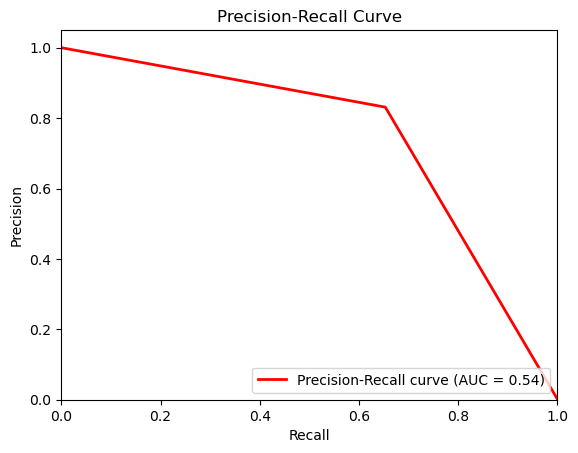

In [6]:
# Calculate precision-recall curve
precision, recall, _ = precision_recall_curve(y_val, y_pred)

# Plot precision-recall curve
plt.figure()
plt.plot(recall, precision, color='red', lw=2, label='Precision-Recall curve (AUC = %0.2f)' % precision_recall_auc)

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.ylim([0.0, 1.05])
plt.xlim([0.0, 1.0])
plt.title('Precision-Recall Curve')
plt.legend(loc='lower right')
plt.show()

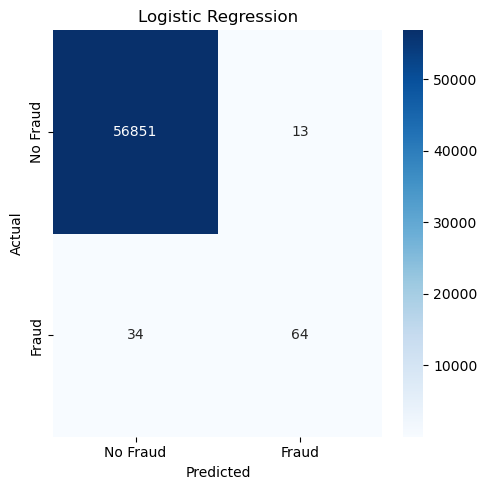

In [7]:
from sklearn.metrics import confusion_matrix

# Create confusion matrix
cm_lr = confusion_matrix(y_val, y_pred)

# Set up the figure suize using subplots
fig, axes = plt.subplots(figsize=(5, 5))

# Create a heatmap
sns.heatmap(cm_lr, xticklabels=['No Fraud', 'Fraud'],  yticklabels=['No Fraud', 'Fraud'],  annot=True, fmt='d', cmap='Blues', ax=axes)
axes.set_title('Logistic Regression')
axes.set_xlabel('Predicted')
axes.set_ylabel('Actual')

plt.tight_layout()
plt.show()


**Questions**:
1. Does adding stratify=y to the train_test_split change the results?
1. In this case, is maximizing precision or recall more important?
1. Does accuracy provide good information in this case?
1. Is this model a good fit for the data?